In [85]:
using Random
using Distributions
using LinearAlgebra
using ForwardDiff
include("../Inversion/Plot.jl")
include("../Inversion/GMBBVI.jl")
include("../Derivative-Free-Variational-Inference/MultiModal.jl")
Random.seed!(111);

[ Info: ("iter = ", 50, " / ", 500)
[ Info: ("iter = ", 100, " / ", 500)
[ Info: ("iter = ", 150, " / ", 500)
[ Info: ("iter = ", 200, " / ", 500)
[ Info: ("iter = ", 250, " / ", 500)
[ Info: ("iter = ", 300, " / ", 500)
[ Info: ("iter = ", 350, " / ", 500)
[ Info: ("iter = ", 400, " / ", 500)
[ Info: ("iter = ", 450, " / ", 500)
[ Info: ("iter = ", 500, " / ", 500)
[ Info: ("iter = ", 50, " / ", 500)
[ Info: ("iter = ", 100, " / ", 500)
[ Info: ("iter = ", 150, " / ", 500)
[ Info: ("iter = ", 200, " / ", 500)
[ Info: ("iter = ", 250, " / ", 500)
[ Info: ("iter = ", 300, " / ", 500)
[ Info: ("iter = ", 350, " / ", 500)
[ Info: ("iter = ", 400, " / ", 500)
[ Info: ("iter = ", 450, " / ", 500)
[ Info: ("iter = ", 500, " / ", 500)
[ Info: ("iter = ", 50, " / ", 500)
[ Info: ("iter = ", 100, " / ", 500)
[ Info: ("iter = ", 150, " / ", 500)
[ Info: ("iter = ", 200, " / ", 500)
[ Info: ("iter = ", 250, " / ", 500)
[ Info: ("iter = ", 300, " / ", 500)
[ Info: ("iter = ", 350, " / ", 500)
[ In

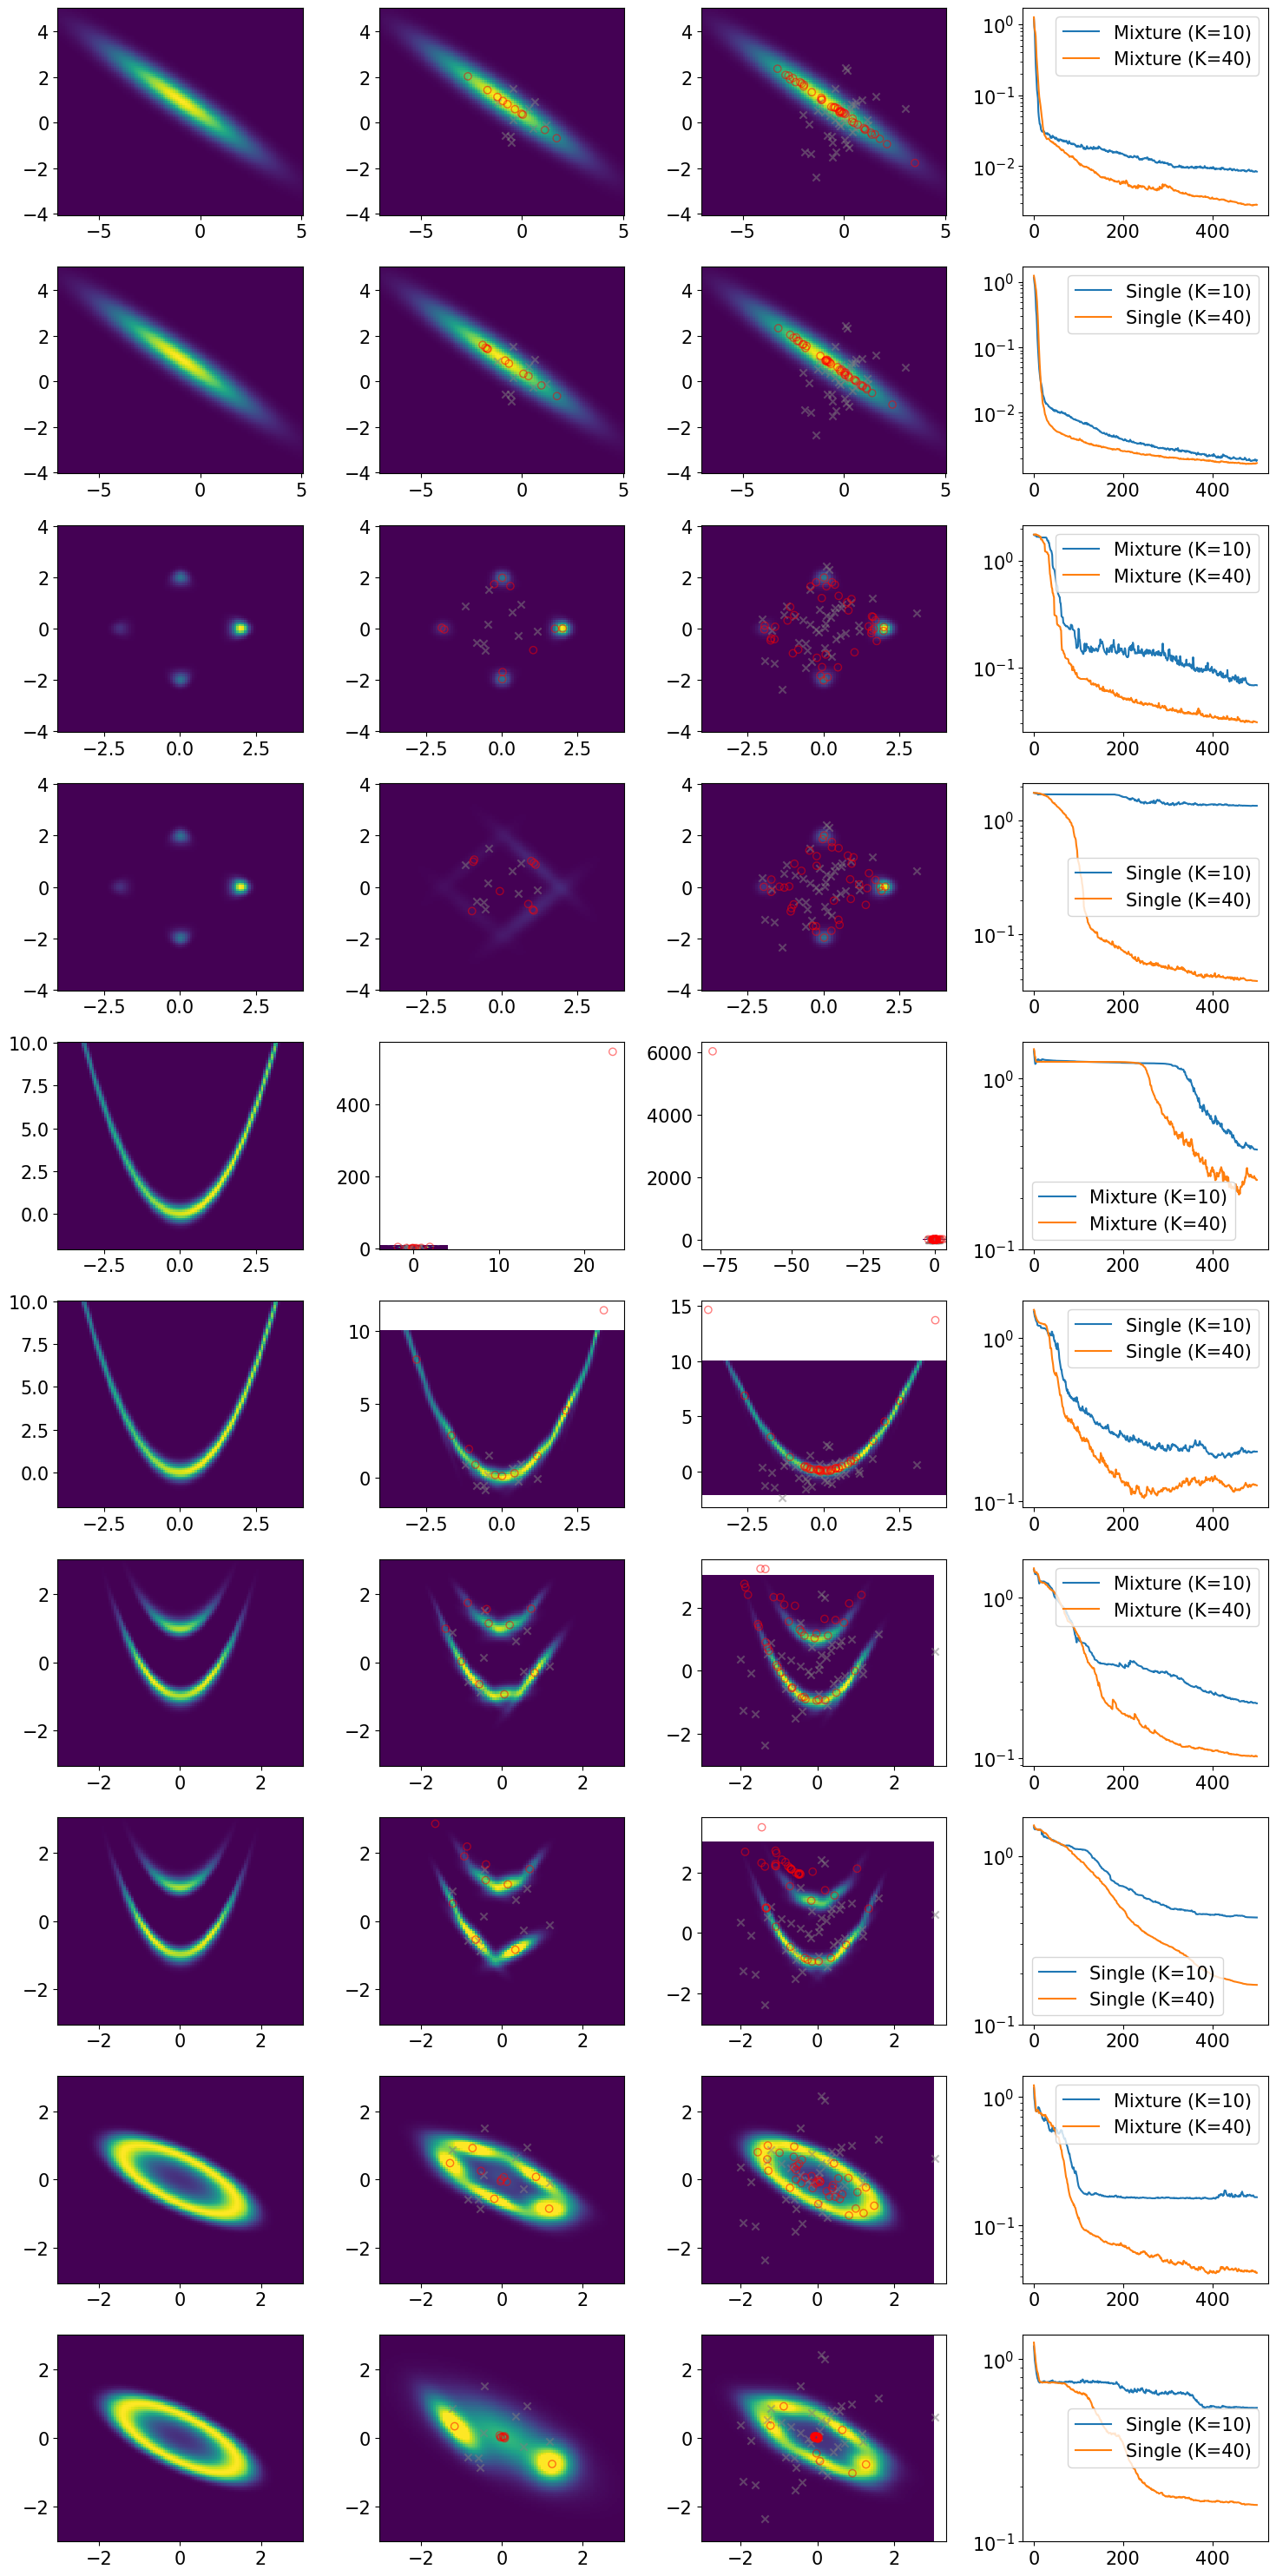

In [86]:
N_modes_array = [10,40]    
fig, ax = PyPlot.subplots(nrows=10, ncols=length(N_modes_array)+2, sharex=false, sharey=false, figsize=(15,30))


N_modes = N_modes_array[end]
x0_w  = ones(N_modes)/N_modes
μ0, Σ0 = [0.0; 0.0], [1.0 0.0; 0.0 1.0]
N_x = length(μ0)
x0_mean, xx0_cov = zeros(N_modes, N_x), zeros(N_modes, N_x, N_x)
for im = 1:N_modes
    x0_mean[im, :] .= rand(MvNormal(zeros(N_x), Σ0)) + μ0
    xx0_cov[im, :, :] .= Σ0
end

N_iter = 500
Nx, Ny = 100,100
N_ens = 5

ση = 1.0
Gtype = "Gaussian"
dt = 0.5
A = [1.0 1.0; 1.0 2.0]
y = [0.0; 1.0; zeros(N_x-2)]
func_args = (y, ση, A , Gtype)
func_F(x) = F(x, func_args)
func_Phi(x)= -logrho(x, func_args)
objs1 = [Gaussian_mixture_BBVI(func_Phi, x0_w[1:N_modes], x0_mean[1:N_modes,:], xx0_cov[1:N_modes,:,:];
        N_iter = N_iter, dt = dt, N_ens = N_ens, gaussian_mixture_sample = true) for N_modes in N_modes_array]
objs2 = [Gaussian_mixture_BBVI(func_Phi, x0_w[1:N_modes], x0_mean[1:N_modes,:], xx0_cov[1:N_modes,:,:];
        N_iter = N_iter, dt = dt, N_ens = N_ens, gaussian_mixture_sample = false) for N_modes in N_modes_array]
visualization_2d(ax[1,:]; Nx = Nx, Ny = Ny, x_lim=[-7.0, 5.0], y_lim=[-4.0, 5.0], func_F=func_F, objs=objs1, label="Mixture")
visualization_2d(ax[2,:]; Nx = Nx, Ny = Ny, x_lim=[-7.0, 5.0], y_lim=[-4.0, 5.0], func_F=func_F, objs=objs2, label="Single")



ση = 1.0
dt = 0.5
Gtype = "Four_modes"
y = [4.2297; 4.2297; 0.5; 0.0; zeros(N_x-2)]
func_args = (y, ση, 0, Gtype)
func_F(x) = F(x, func_args)
func_Phi(x)= -logrho(x, func_args)
objs1 = [Gaussian_mixture_BBVI(func_Phi, x0_w[1:N_modes], x0_mean[1:N_modes,:], xx0_cov[1:N_modes,:,:];
        N_iter = N_iter, dt = dt, N_ens=N_ens, gaussian_mixture_sample=true) for N_modes in N_modes_array]
objs2 = [Gaussian_mixture_BBVI(func_Phi, x0_w[1:N_modes], x0_mean[1:N_modes,:], xx0_cov[1:N_modes,:,:];
        N_iter = N_iter, dt = dt, N_ens=N_ens, gaussian_mixture_sample=false) for N_modes in N_modes_array]
visualization_2d(ax[3,:]; Nx = Nx, Ny = Ny, x_lim=[-4.0, 4.0], y_lim=[-4.0, 4.0], func_F=func_F, objs=objs1, label="Mixture")
visualization_2d(ax[4,:]; Nx = Nx, Ny = Ny, x_lim=[-4.0, 4.0], y_lim=[-4.0, 4.0], func_F=func_F, objs=objs2, label="Single")



ση = [sqrt(10.0); ones(N_x-2)]
Gtype = "Banana"
dt = 0.2
λ = 10.0
y = [0.0; 1.0; zeros(N_x-2)]
func_args = (y, ση, λ , Gtype)
func_F(x) = F(x, func_args)
func_Phi(x)= -logrho(x, func_args)
objs1 = [Gaussian_mixture_BBVI(func_Phi, x0_w[1:N_modes], x0_mean[1:N_modes,:], xx0_cov[1:N_modes,:,:];
        N_iter = N_iter, dt = dt, N_ens=N_ens, gaussian_mixture_sample=true) for N_modes in N_modes_array]
objs2 = [Gaussian_mixture_BBVI(func_Phi, x0_w[1:N_modes], x0_mean[1:N_modes,:], xx0_cov[1:N_modes,:,:];
        N_iter = N_iter, dt = dt, N_ens=N_ens, gaussian_mixture_sample=false) for N_modes in N_modes_array]
visualization_2d(ax[5,:]; Nx = Nx, Ny = Ny, x_lim=[-4.0, 4.0], y_lim=[-2.0, 10.0], func_F=func_F, objs=objs1, label="Mixture")
visualization_2d(ax[6,:]; Nx = Nx, Ny = Ny, x_lim=[-4.0, 4.0], y_lim=[-2.0, 10.0], func_F=func_F, objs=objs2, label="Single")



ση = [0.3; 1.0; 1.0; ones(N_x-2)]
Gtype = "Double_banana"
dt = 0.1
λ = 100.0
y = [log(λ+1); 0.0; 0.0; zeros(N_x-2)]
func_args = (y, ση, λ , Gtype)
func_F(x) = F(x, func_args)
func_Phi(x)= -logrho(x, func_args)
objs1 = [Gaussian_mixture_BBVI(func_Phi, x0_w[1:N_modes], x0_mean[1:N_modes,:], xx0_cov[1:N_modes,:,:];
        N_iter = N_iter, dt = dt, N_ens=N_ens, gaussian_mixture_sample=true) for N_modes in N_modes_array]
objs2 = [Gaussian_mixture_BBVI(func_Phi, x0_w[1:N_modes], x0_mean[1:N_modes,:], xx0_cov[1:N_modes,:,:];
        N_iter = N_iter, dt = dt, N_ens=N_ens, gaussian_mixture_sample=false) for N_modes in N_modes_array]
visualization_2d(ax[7,:]; Nx = Nx, Ny = Ny, x_lim=[-3.0, 3.0], y_lim=[-3.0, 3.0], func_F=func_F, objs=objs1, label="Mixture")
visualization_2d(ax[8,:]; Nx = Nx, Ny = Ny, x_lim=[-3.0, 3.0], y_lim=[-3.0, 3.0], func_F=func_F, objs=objs2, label="Single")


ση = [0.5; ones(N_x-2)]
Gtype = "Circle"
dt = 0.2
A = [1.0 1.0; 1.0 2.0]
y = [1.0; zeros(N_x-2)]
func_args = (y, ση, A , Gtype)
func_F(x) = F(x, func_args)
func_Phi(x)= -logrho(x, func_args)
objs1 = [Gaussian_mixture_BBVI(func_Phi, x0_w[1:N_modes], x0_mean[1:N_modes,:], xx0_cov[1:N_modes,:,:];
        N_iter = N_iter, dt = dt, N_ens=N_ens, gaussian_mixture_sample=true) for N_modes in N_modes_array]
objs2 = [Gaussian_mixture_BBVI(func_Phi, x0_w[1:N_modes], x0_mean[1:N_modes,:], xx0_cov[1:N_modes,:,:];
        N_iter = N_iter, dt = dt, N_ens=N_ens, gaussian_mixture_sample=false) for N_modes in N_modes_array]
visualization_2d(ax[9,:]; Nx = Nx, Ny = Ny, x_lim=[-3.0, 3.0], y_lim=[-3.0, 3.0], func_F=func_F, objs=objs1, label="Mixture")
visualization_2d(ax[10,:]; Nx = Nx, Ny = Ny, x_lim=[-3.0, 3.0], y_lim=[-3.0, 3.0], func_F=func_F, objs=objs2, label="Single")


fig.tight_layout()
fig.savefig("BBVI-exp-ratio-quasi.pdf")